In [49]:
from utils.paths import DATABASE_DIR,RAW_DIR,PREDICTIONS_DIR,EXP_RESULT
from models_scripts.gp_workflow import ExperimentalGPApproach
from models_scripts.prediction_utils import save_experiment_outputs

from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength, predict_composition_space
from data.splitting import DataSplitter
from data.Descriptors import AlloyDescriptorCalculator
from plots.TernaryPlot import plot_ternary_heatmap,plot_train_test_ternary

from evaluation.evaluation import compute_permutation_importance, importance_to_df

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary

Load data
1. Experimental data (1552)
2. Resistivity calculation using ANN

In [19]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

In [50]:
df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")
# --- Merge full data ---
df_merged = merge_data(df_optical, df_comp)

# ---- Wavelength selection ----
tern_1550 = filter_by_wavelength(df_merged, 1300).copy()
tern_1550 = tern_1550.reset_index(drop=True)
tern_1550 = merge_data(tern_1550, df_resis_ANN[["ID", "resistivity"]])

X = tern_1550[["Cu", "Ni", "Al", "resistivity"]].copy()
y = tern_1550["e2"].copy()

splitter = DataSplitter(
    test_size=0.20,
    random_state=42,
    split_method="cluster", 
    n_clusters=8,
    force_pure_train=True
)

split_dict = splitter.split(X, y)

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


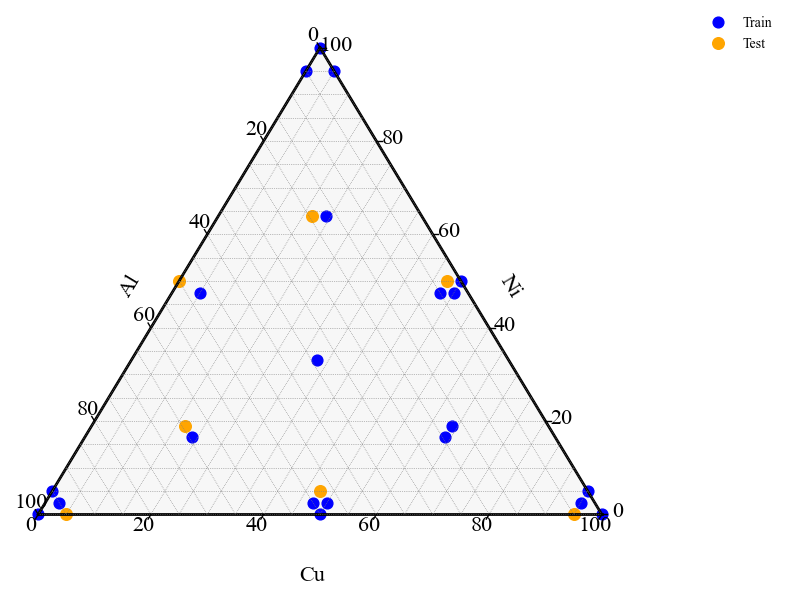

In [51]:
fig, tax = plot_train_test_ternary(split_dict)
fig.savefig(EXP_RESULT/"exp_01_train_test.svg", format="svg", bbox_inches="tight")

Load the descriptors

In [11]:
calc = AlloyDescriptorCalculator()
descriptor_spec = {
    "atomic_radius": ["avg","mismatch","range"],
    "metallic_radius": ["avg","mismatch","range"],
    "electronegativity_pauling": ["avg","mismatch","range"],
    "electronegativity_allen": ["avg","mismatch","range"],
    "valence_electrons": ["avg","mismatch","range"],
    "density": ["avg","mismatch","range"],
    "electron_affinity": ["avg","mismatch","range"],
    "ionization_energy_1": ["avg","mismatch","range"],
    "ionization_energy_2": ["avg","mismatch","range"],
    "valence_s": ["avg","mismatch","range"],
    "valence_d": ["avg","mismatch","range"]
}

x_train = calc.transform(split_dict['X_train'], descriptor_spec=descriptor_spec, include_entropy=True)
x_test = calc.transform(split_dict['X_test'], descriptor_spec=descriptor_spec, include_entropy=True)

In [15]:
y_train = split_dict['y_train']
y_test = split_dict['y_test']

In [ ]:
# Property calculator (R variables)
calc = AlloyDescriptorCalculator()
descriptor_spec = {
    "metallic_radius": ["avg","mismatch"],
    "valence_electrons": ["avg"],
    "density": ["avg"],
    "ionization_energy_2": ["avg","mismatch"],
    "valence_s": ["mismatch"],
    "valence_d": ["mismatch"]
}

x_train = calc.transform(split_dict['X_train'], descriptor_spec=descriptor_spec, include_entropy=True)
x_test = calc.transform(split_dict['X_test'], descriptor_spec=descriptor_spec, include_entropy=True)

# Optical properties
y_train = split_dict['y_train']
y_test = split_dict['y_test']

In [6]:
x_train = x_train.drop(columns=['Cu','Ni','Al','resistivity'])
x_test = x_test.drop(columns=['Cu','Ni','Al','resistivity'])

Variable for R

In [37]:
calc = AlloyDescriptorCalculator()
descriptor_spec = {
    "metallic_radius": ["avg","mismatch"],
    "valence_electrons": ["avg"],
    "density": ["avg"],
    "ionization_energy_2": ["avg","mismatch"],
    "valence_s": ["mismatch"],
    "valence_d": ["mismatch"]
}

x_train = calc.transform(split_dict['X_train'], descriptor_spec=descriptor_spec, include_entropy=False)
x_test = calc.transform(split_dict['X_test'], descriptor_spec=descriptor_spec, include_entropy=False)

In [38]:
x_space = calc.transform(comp_space[['Cu','Ni','Al']], descriptor_spec=descriptor_spec, include_entropy=True)

In [39]:
x_space = x_space.drop(columns=['Cu','Ni','Al'])

In [40]:
x_space.tail(5)

,mr_avg,del_mr,ve_avg,d_avg,ie2_avg,del_ie2,del_vs,del_vd,S
1321,118.08,1.074058,10.82,8.8336,20.220642,0.357629,0.195959,1.422111,1.626801
1322,117.88,0.587878,10.96,8.9576,20.207448,0.416130,0.195959,0.391918,1.396288
1323,118.14,0.980000,10.84,8.8348,20.263113,0.204938,0.140000,1.400000,0.815097
1324,117.94,0.420000,10.98,8.9588,20.249919,0.297297,0.140000,0.280000,0.815097
1325,118.00,0.000000,11.00,8.9600,20.292390,0.000000,0.000000,0.000000,-0.000000


In [33]:
x_train = x_train.drop(columns=['resistivity'])
x_test = x_test.drop(columns=['resistivity'])

In [ ]:
# Save data to R

x_train.to_csv("/Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Experimental design/x_train.csv", index=False)
x_test.to_csv("/Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Experimental design/x_test.csv", index=False)
y_train.to_csv("/Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Experimental design/y_train.csv", index=False)
y_test.to_csv("/Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Experimental design/y_test.csv", index=False)

In [41]:
x_space.to_csv("/Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Experimental design/x_space.csv", index=False)

In [ ]:
import pickle

gpy_dic = {
    "X_train": x_train,
    "X_test": x_test,
    "y_train": y_train,
    "y_test": y_test
}

with open("gpy_dic.pkl", "wb") as f:
    pickle.dump(gpy_dic, f)

Gaussian Process mean  = 0

In [ ]:
gp_exp = ExperimentalGPApproach(
    random_state=42,
    n_splits=5,
    scoring="r2",
    n_restarts_optimizer=5,
)

results = gp_exp.fit_and_evaluate(
    X_train=x_train,
    y_train=y_train,
    X_test=x_test,
    y_test=y_test,
)

model = gp_exp.model_

print("Best CV score:", results["best_score_cv"])
print("Best params:")
print(results["best_params"])
print("Train metrics:", results["train_metrics"])
print("Test metrics:", results["test_metrics"])

In [ ]:
space_predictions_df = predict_composition_space(
    comp_space=comp_space,
    calc=calc,
    descriptor_spec=descriptor_spec,
    model=model,
    include_entropy=True
)

In [31]:
save_experiment_outputs(
    exp_name="exp_02",
    results=results,
    model=model,
    x_train=x_train,
    x_test=x_test,
    y_test=y_test,
    split_dict=split_dict,
)

In [ ]:
plot_ternary_heatmap(
    df=space_predictions_df,
    value_col="e2",
    duplicate_handling="mean",
    save_path = EXP_RESULT/"exp_01_e2.svg"
)

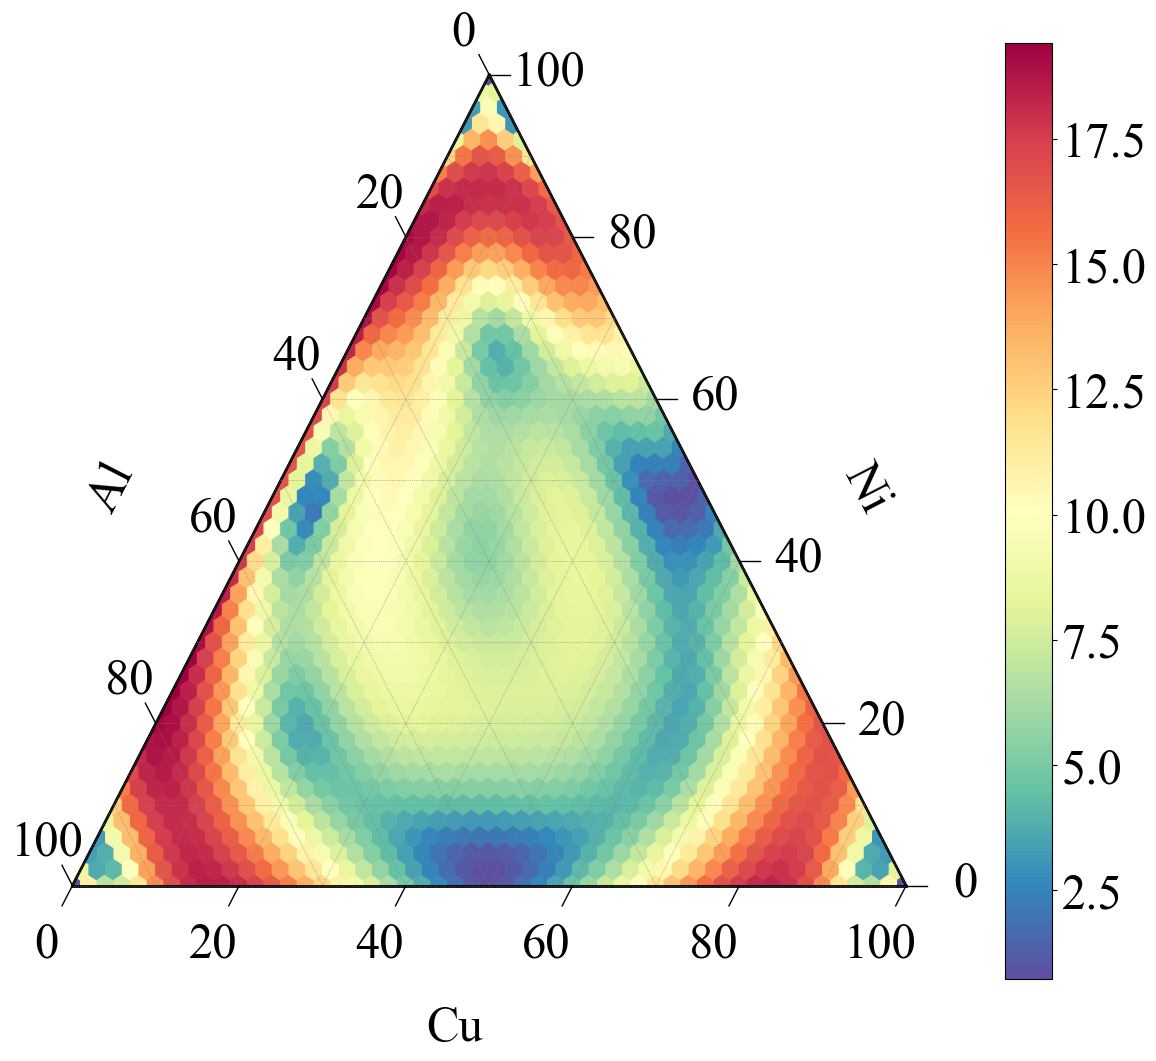

(<Figure size 1200x1000 with 2 Axes>, TernaryAxesSubplot: 391477582)

In [ ]:
plot_ternary_heatmap(
    df=space_predictions_df,
    value_col="std",
    duplicate_handling="mean",
    save_path = EXP_RESULT/"exp_01_std.svg"
)

GP R2 Model results

In [ ]:
df_gp_R = pd.read_csv("/Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Experimental design/gp_predictions.csv")
gp_r = pd.concat([comp_space[['Cu','Ni','Al']], df_gp_R], axis=1)

In [46]:
gp_r.head(5)

,Cu,Ni,Al,y_pred,y_sd
0,0.0,0.00,1.00,56.837337,3.371748e-07
1,0.0,0.02,0.98,83.336819,6.119482e+00
2,0.0,0.04,0.96,94.285608,2.540044e+00
3,0.0,0.06,0.94,96.677657,2.572200e+00
4,0.0,0.08,0.92,93.943831,7.151427e+00


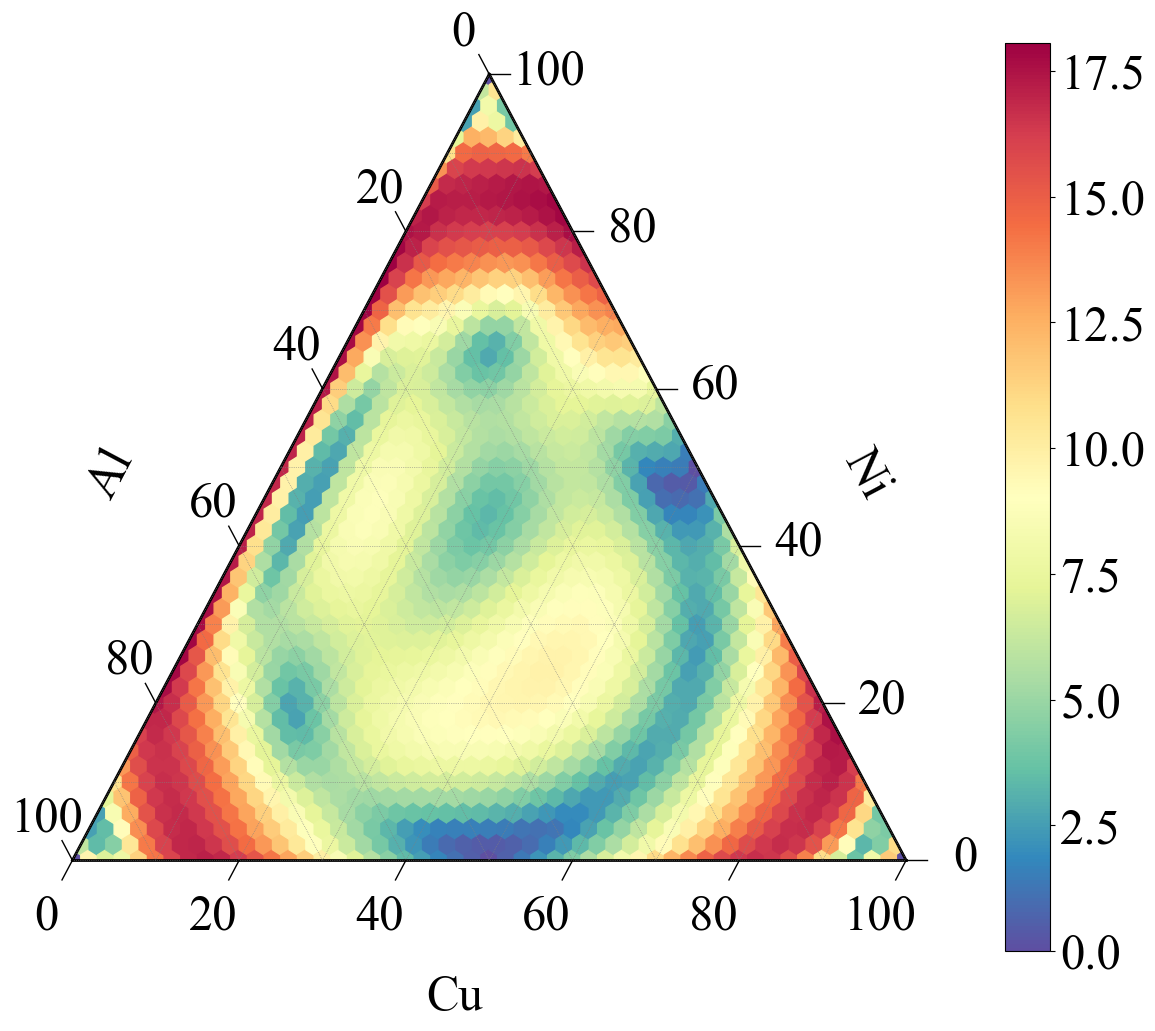

(<Figure size 1200x1000 with 2 Axes>, TernaryAxesSubplot: 393678386)

In [48]:
plot_ternary_heatmap(
    df=gp_r,
    value_col="y_sd",
    duplicate_handling="mean"
)

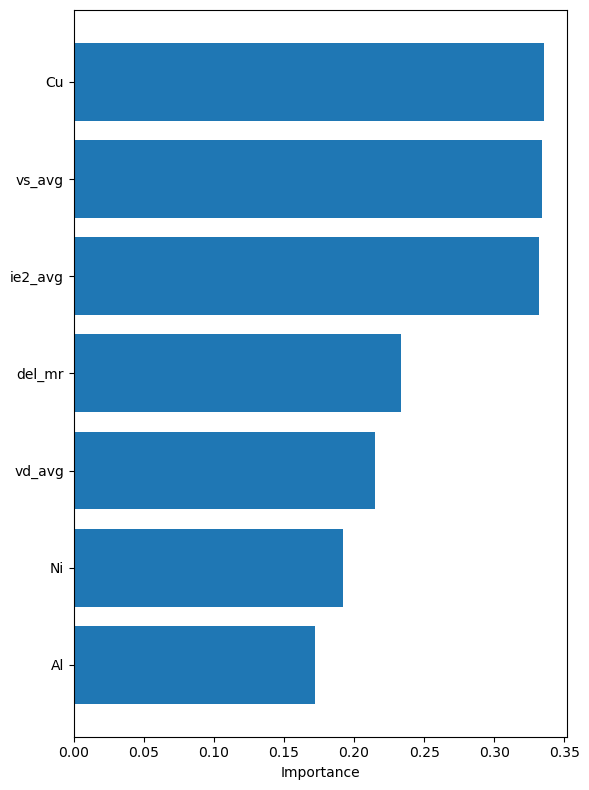

In [35]:
feature_names = x_test.columns

imp = compute_permutation_importance(model, x_test, y_test)
df_imp = importance_to_df(imp, feature_names)


plt.figure(figsize=(6,8))
plt.barh(df_imp["feature"], df_imp["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
df_wave = pd.read_csv(PREDICTIONS_DIR/"GP-Experiments/GP_wavelength_r2.csv")

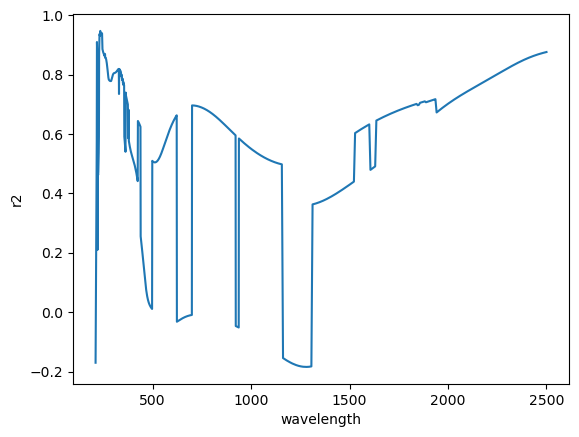

In [ ]:
import matplotlib.pyplot as plt

df_wave = df_wave.sort_values('wavelength')
plt.plot(df_wave['wavelength'], df_wave['r2'])
plt.xlabel('wavelength')
plt.ylabel('r2')
plt.show()

In [ ]:
import pickle

with open("gpy_dic.pkl", "rb") as f:
    data = pickle.load(f)

x_train = data["X_train"]
x_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]

In [ ]:
from models_scripts.gp_GPy import GPyMeanModel

model = GPyMeanModel()

model.fit(x_train, y_train)

metrics = model.evaluate(x_test, y_test)
print(metrics)

y_pred, y_std = model.predict(x_test)

reconstraining parameters gp.Gaussian_noise.variance


Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s02  0008   1.322170e+01   4.641630e+02 
    00s03  0015   1.008222e+01   1.535602e+01 
    00s09  0044   6.555373e+00   3.437831e+01 
    00s17  0069   5.793564e+00   4.869248e-01 
    00s19  0083   5.609188e+00   2.301095e+00 
    00s47  0382   3.812144e+00   6.970184e-01 
Runtime:     00s47
Optimization status: Converged

{'r2': -0.33912747098730756, 'rmse': 18.64316737895431, 'mse': 347.5676899197061}
